In [7]:
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from pathlib import Path
import contextily as cx
from geopy.geocoders import ArcGIS
import matplotlib.patches as mpatches
from pyproj import Transformer
from sklearn.cluster import DBSCAN
from shapely.geometry import MultiPoint

## Clean Data

### CSV

In [8]:
delivery_data = pd.read_csv("Meituan_final.csv")

In [9]:
delivery_data.head()

,shop_name,lng,lat,address,module,time
0,田老师红烧肉（中关村物美店）,116.311182,39.981863,中关村,拼好饭,中午
1,汉堡王(北京融科资讯30354店),116.320193,39.981628,中关村,拼好饭,中午
2,瑞幸咖啡(中关村科贸电子城店),116.310960,39.982246,中关村,拼好饭,中午
3,桃园煲仔饭（五道口店）,116.327612,39.986787,中关村,拼好饭,中午
4,汉堡王（五道口餐厅19195店）,116.327834,39.991205,中关村,拼好饭,中午


Coordinates are treated as WGS84 in the analysis

In [10]:
delivery_data.shape

(7907, 6)

In [11]:
delivery_data.isna().sum().sort_values(ascending=False)

shop_name    0
lng          0
lat          0
address      0
module       0
time         0
dtype: int64

In [12]:
delivery_data[["lng", "lat"]].describe()

,lng,lat
count,7907.000000,7907.000000
mean,116.390023,39.925111
std,0.074580,0.074752
min,116.264775,39.770295
25%,116.327881,39.836164
50%,116.360737,39.966811
75%,116.471797,39.986540
max,116.599347,40.052184


In [13]:
mapped_data = delivery_data.dropna(subset=["lng", "lat"]).copy()

delivery_gdf = gpd.GeoDataFrame(
    mapped_data,
    geometry=gpd.points_from_xy(mapped_data["lng"], mapped_data["lat"]),
    crs="EPSG:4326",
)

In [14]:
delivery_gdf[["shop_name", "lng", "lat", "geometry"]].head()

,shop_name,lng,lat,geometry
0,田老师红烧肉（中关村物美店）,116.311182,39.981863,POINT (116.31118 39.98186)
1,汉堡王(北京融科资讯30354店),116.320193,39.981628,POINT (116.32019 39.98163)
2,瑞幸咖啡(中关村科贸电子城店),116.310960,39.982246,POINT (116.31096 39.98225)
3,桃园煲仔饭（五道口店）,116.327612,39.986787,POINT (116.32761 39.98679)
4,汉堡王（五道口餐厅19195店）,116.327834,39.991205,POINT (116.32783 39.9912)


In [15]:
delivery_gdf_web = delivery_gdf.to_crs(epsg=3857)

In [16]:
delivery_gdf_web.crs

<Projected CRS: EPSG:3857>
Name: WGS 84 / Pseudo-Mercator
Axis Info [cartesian]:
- X[east]: Easting (metre)
- Y[north]: Northing (metre)
Area of Use:
- name: World between 85.06°S and 85.06°N.
- bounds: (-180.0, -85.06, 180.0, 85.06)
Coordinate Operation:
- name: Popular Visualisation Pseudo-Mercator
- method: Popular Visualisation Pseudo Mercator
Datum: World Geodetic System 1984 ensemble
- Ellipsoid: WGS 84
- Prime Meridian: Greenwich

### Shp

In [17]:
beijing_boundary = gpd.read_file("Beijing_3857/北京市_3857.shp")

In [18]:
beijing_boundary.crs
beijing_boundary.head()

,Lon,Lat,F_AREA,City_CODE,UUID,Level1,Level2,Level1_cn,Level2_cn,geometry
0,115.68048,39.59239,1.004836,110100,7348,1,101,居住用地,居住用地,"MULTIPOLYGON (((12877791.115 4807218.407, 1287..."
1,116.07637,39.57219,0.177722,110100,7349,5,502,公共管理和服务用地,教育科研用地,"POLYGON ((12921210 4804044.14, 12921210 480406..."
2,115.71293,39.55558,0.198087,110100,7350,5,502,公共管理和服务用地,教育科研用地,"MULTIPOLYGON (((12880494.652 4802570.322, 1288..."
3,115.71293,39.55558,0.037525,110100,7351,5,505,公共管理和服务用地,公园与绿地用地,"POLYGON ((12883784.272 4798266.08, 12883770 47..."
4,115.69333,39.56553,1.124176,110100,7352,3,301,工业用地,工业用地,"MULTIPOLYGON (((12878357.312 4803118.595, 1287..."


### Observation Points

In [19]:
observation_sites = pd.DataFrame(
    {
        "address": ["五道口", "青年路", "中关村", "望京SOHO", "丰台"],
        "full_address": [
            "北京市海淀区荷清路与成府路交叉路口往西南约200米 华清嘉园",
            "北京市朝阳区朝阳北路106号 青年汇佳园",
            "北京市海淀区中关村大街18号 中关村科贸电子城",
            "北京市朝阳区望京街10号 望京SOHO",
            "北京市丰台区南苑槐房西路 新宫家园北区",
        ],
    }
)

geolocator = ArcGIS(timeout=10)


def geocode_address(address):

    location = geolocator.geocode(address)

    if location is None:

        return pd.Series({"lat": None, "lng": None})

    return pd.Series({"lat": location.latitude, "lng": location.longitude})


observation_sites[["lat", "lng"]] = observation_sites["full_address"].apply(
    geocode_address
)

observation_sites

,address,full_address,lat,lng
0,五道口,北京市海淀区荷清路与成府路交叉路口往西南约200米 华清嘉园,40.007595,116.330008
1,青年路,北京市朝阳区朝阳北路106号 青年汇佳园,39.922333,116.536444
2,中关村,北京市海淀区中关村大街18号 中关村科贸电子城,39.974956,116.311292
3,望京SOHO,北京市朝阳区望京街10号 望京SOHO,39.993453,116.472990
4,丰台,北京市丰台区南苑槐房西路 新宫家园北区,39.804049,116.360300


In [20]:
observation_gdf = gpd.GeoDataFrame(
    observation_sites.copy(),
    geometry=gpd.points_from_xy(observation_sites["lng"], observation_sites["lat"]),
    crs="EPSG:4326",
)

In [21]:
observation_gdf_web = observation_gdf.to_crs(epsg=3857)

In [22]:
delivery_gdf_web["address"].unique()

<ArrowStringArray>
['中关村', '丰台区', '五道口', '望京SOHO', '青年路']
Length: 5, dtype: str

In [23]:
name_map = {
    "五道口": "Wudaokou",
    "青年路": "Qingnianlu",
    "中关村": "Zhongguancun",
    "望京SOHO": "Wangjing SOHO",
    "丰台区": "Fengtai",
    "丰台": "Fengtai",
}

observation_gdf_web["address_en"] = observation_gdf_web["address"].map(name_map)

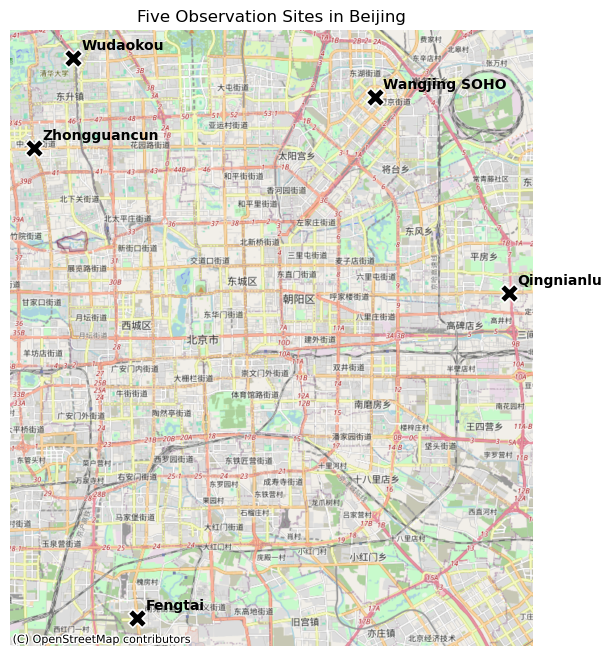

In [24]:
fig, ax = plt.subplots(figsize=(8, 8))

observation_gdf_web.plot(
    ax=ax,
    marker="X",
    markersize=180,
    color="black",
    edgecolor="white",
    linewidth=1.2,
    zorder=10,
)

cx.add_basemap(ax, source=cx.providers.OpenStreetMap.Mapnik)

for _, row in observation_gdf_web.iterrows():
    ax.annotate(
        row["address_en"],
        (row.geometry.x, row.geometry.y),
        xytext=(6, 6),
        textcoords="offset points",
        fontsize=10,
        fontweight="bold",
        zorder=11,
    )

ax.set_title("Five Observation Sites in Beijing")
ax.set_axis_off()

plt.show()

## Darwing Diagrams

### name projection

In [25]:
address_name_map = {
    "五道口": "Wudaokou",
    "青年路": "Qingnianlu",
    "中关村": "Zhongguancun",
    "望京SOHO": "Wangjing SOHO",
    "丰台": "Fengtai",
    "丰台区": "Fengtai",
}

In [26]:
delivery_gdf_web["address_en"] = (
    delivery_gdf_web["address"]
    .astype(str)
    .map(address_name_map)
    .fillna(delivery_gdf_web["address"].astype(str))
)

In [27]:
delivery_gdf_web[["address", "address_en"]].drop_duplicates()

,address,address_en
0,中关村,Zhongguancun
1598,丰台区,Fengtai
3272,五道口,Wudaokou
4992,望京SOHO,Wangjing SOHO
6427,青年路,Qingnianlu


In [28]:
observation_gdf_web["address_en"] = (
    observation_gdf_web["address"]
    .astype(str)
    .map(address_name_map)
    .fillna(observation_gdf_web["address"].astype(str))
)

In [29]:
observation_gdf_web[
    [
        "address",
        "address_en",
        "lng",
        "lat",
        "geometry",
    ]
]

,address,address_en,lng,lat,geometry
0,五道口,Wudaokou,116.330008,40.007595,POINT (12949797.242 4867046.064)
1,青年路,Qingnianlu,116.536444,39.922333,POINT (12972777.565 4854662.306)
2,中关村,Zhongguancun,116.311292,39.974956,POINT (12947713.809 4862303.56)
3,望京SOHO,Wangjing SOHO,116.472990,39.993453,POINT (12965713.911 4864990.969)
4,丰台,Fengtai,116.360300,39.804049,POINT (12953169.32 4837507.904)


### World Coordinate System Calibration

原始数据 4326
↓
为了画图，转成 3857
↓
为了按米聚类，临时转成 32650
↓
聚类 hull 做完后，再转回 3857 画上去

In [30]:
transformer = Transformer.from_crs(
    "EPSG:4326",
    "EPSG:3857",
    always_xy=True,
)

inv_transformer = Transformer.from_crs(
    "EPSG:3857",
    "EPSG:4326",
    always_xy=True,
)

In [31]:
forbidden_lon = 116.397
forbidden_lat = 39.908

center_x, center_y = transformer.transform(
    forbidden_lon,
    forbidden_lat,
)

center_x, center_y

(12957254.769864663, 4852582.082864691)

In [32]:
lon_back, lat_back = inv_transformer.transform(
    center_x,
    center_y,
)

lon_back, lat_back

(116.39699999999998, 39.908)

### Diagram Set Up

In [33]:
def make_base_map():

    fig, ax = plt.subplots(figsize=(12, 12))

    ax.set_facecolor("#ffe5cc")

    beijing_boundary.plot(
        ax=ax,
        facecolor="#ffe7d6",
        edgecolor="#c89a70",
        linewidth=0.25,
        zorder=0,
    )

    return fig, ax

### color address

In [34]:
delivery_gdf_web["address_en"] = delivery_gdf_web["address_en"].astype("category")

In [35]:
delivery_gdf_web["address_en"].dtype

CategoricalDtype(categories=['Fengtai', 'Qingnianlu', 'Wangjing SOHO', 'Wudaokou',
                  'Zhongguancun'],
, ordered=False, categories_dtype=str)

In [36]:
cmap = plt.get_cmap("tab10")

address_colors = {name: cmap(i) for i, name in enumerate(address_categories)}

address_colors

NameError: name 'address_categories' is not defined

In [ ]:
delivery_gdf_web["plot_color"] = [
    address_colors[value] for value in delivery_gdf_web["address_en"]
]

In [ ]:
delivery_gdf_web[["address_en", "plot_color"]].head()

,address_en,plot_color
0,Zhongguancun,"(0.5803921568627451, 0.403921568627451, 0.7411..."
1,Zhongguancun,"(0.5803921568627451, 0.403921568627451, 0.7411..."
2,Zhongguancun,"(0.5803921568627451, 0.403921568627451, 0.7411..."
3,Zhongguancun,"(0.5803921568627451, 0.403921568627451, 0.7411..."
4,Zhongguancun,"(0.5803921568627451, 0.403921568627451, 0.7411..."


### Draw Restaurants

In [ ]:
def draw_restaurants(ax):

    delivery_gdf_web.plot(
        ax=ax,
        color=delivery_gdf_web["plot_color"],
        markersize=16,
        alpha=0.95,
        edgecolor="white",
        linewidth=0.35,
        zorder=3,
    )

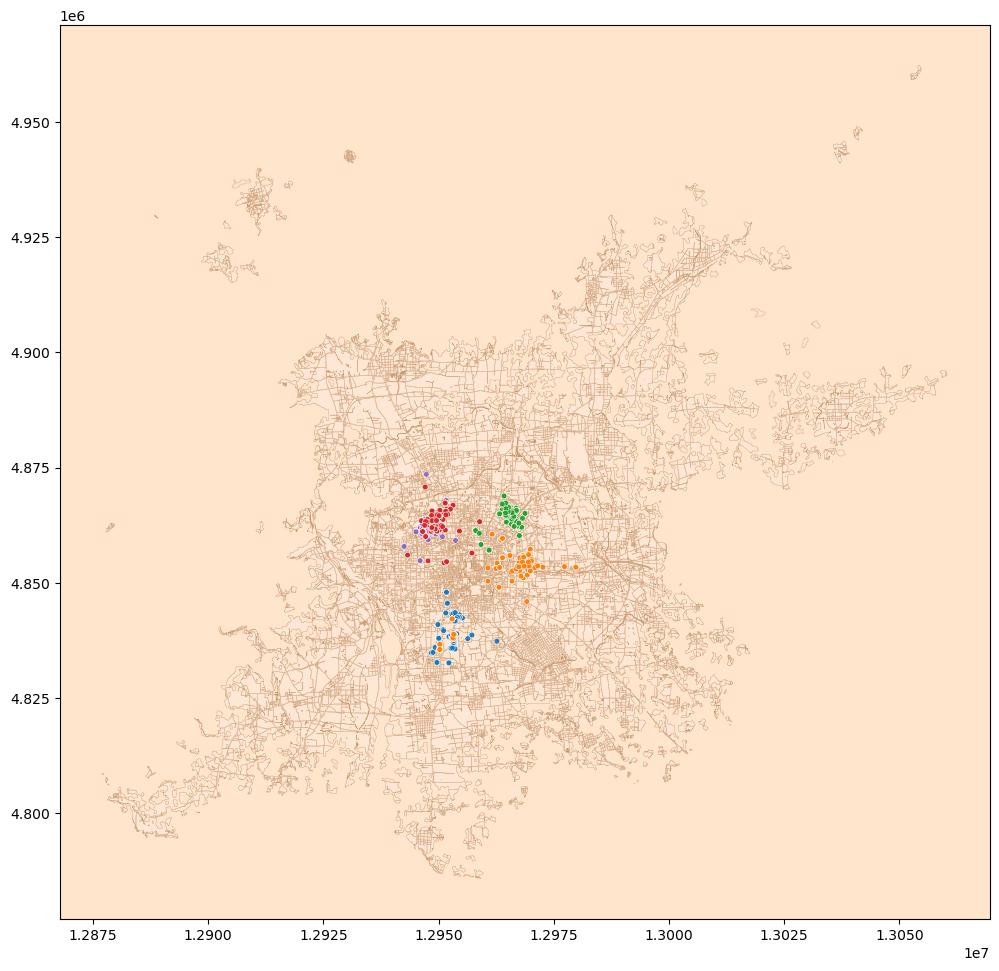

In [ ]:
fig, ax = make_base_map()

draw_restaurants(ax)

plt.show()

### overall range hull

In [ ]:
def draw_overall_hulls(ax):

    for name, group in delivery_gdf_web.groupby(
        "address_en",
        observed=True,
    ):

        hull = group.geometry.union_all().convex_hull

        if hull.geom_type != "Polygon":
            continue

        x, y = hull.exterior.xy

        ax.plot(
            x,
            y,
            color=address_colors[name],
            linewidth=0.9,
            alpha=0.35,
            zorder=2,
        )

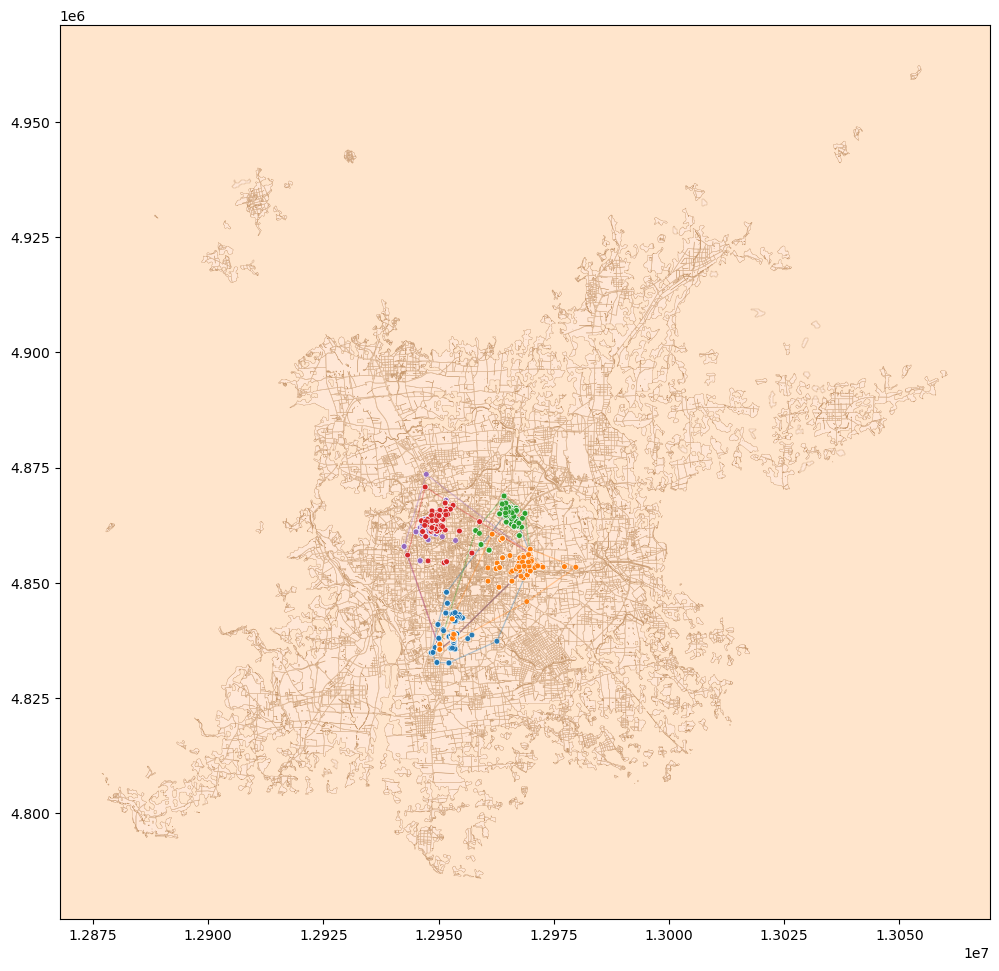

In [ ]:
fig, ax = make_base_map()

draw_overall_hulls(ax)
draw_restaurants(ax)

plt.show()

In [ ]:
def draw_cluster_hulls(ax):

    for cluster in cluster_hulls:

        hull = cluster["geometry"]
        name = cluster["address_en"]

        if hull.geom_type != "Polygon":
            continue

        x, y = hull.exterior.xy

        hull_color = address_colors.get(
            name,
            "#0b3a8c",
        )

        ax.fill(
            x,
            y,
            facecolor=hull_color,
            alpha=0.12,
            linewidth=0,
            zorder=1.5,
        )

        ax.plot(
            x,
            y,
            color=hull_color,
            linewidth=1.2,
            alpha=0.65,
            zorder=2,
        )

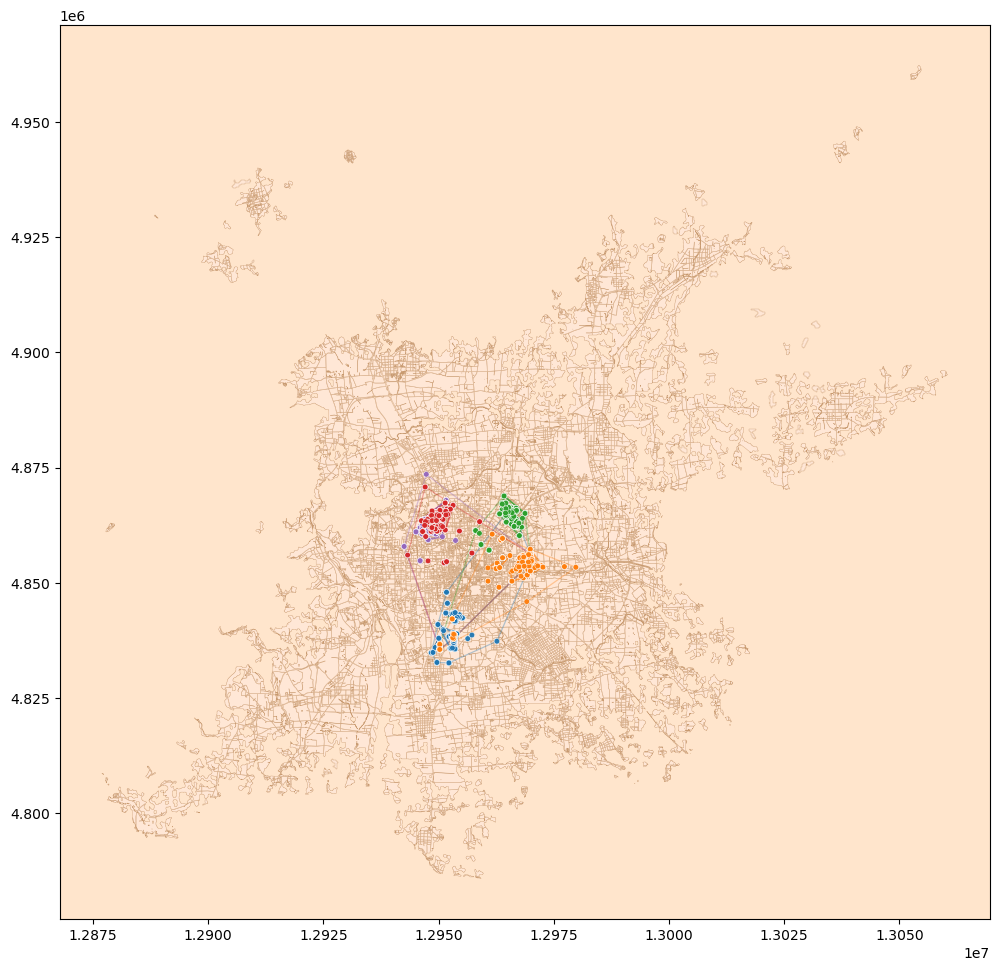

In [ ]:
fig, ax = make_base_map()

draw_overall_hulls(ax)
draw_cluster_hulls(ax)
draw_restaurants(ax)

plt.show()

In [ ]:
def draw_observation_sites(ax):

    observation_gdf_web.plot(
        ax=ax,
        marker="X",
        markersize=180,
        color="black",
        edgecolor="white",
        linewidth=1.2,
        zorder=10,
    )

    for _, row in observation_gdf_web.iterrows():

        ax.annotate(
            row["address_en"],
            (
                row.geometry.x,
                row.geometry.y,
            ),
            xytext=(7, 7),
            textcoords="offset points",
            fontsize=9,
            fontweight="bold",
            color="black",
            zorder=11,
        )

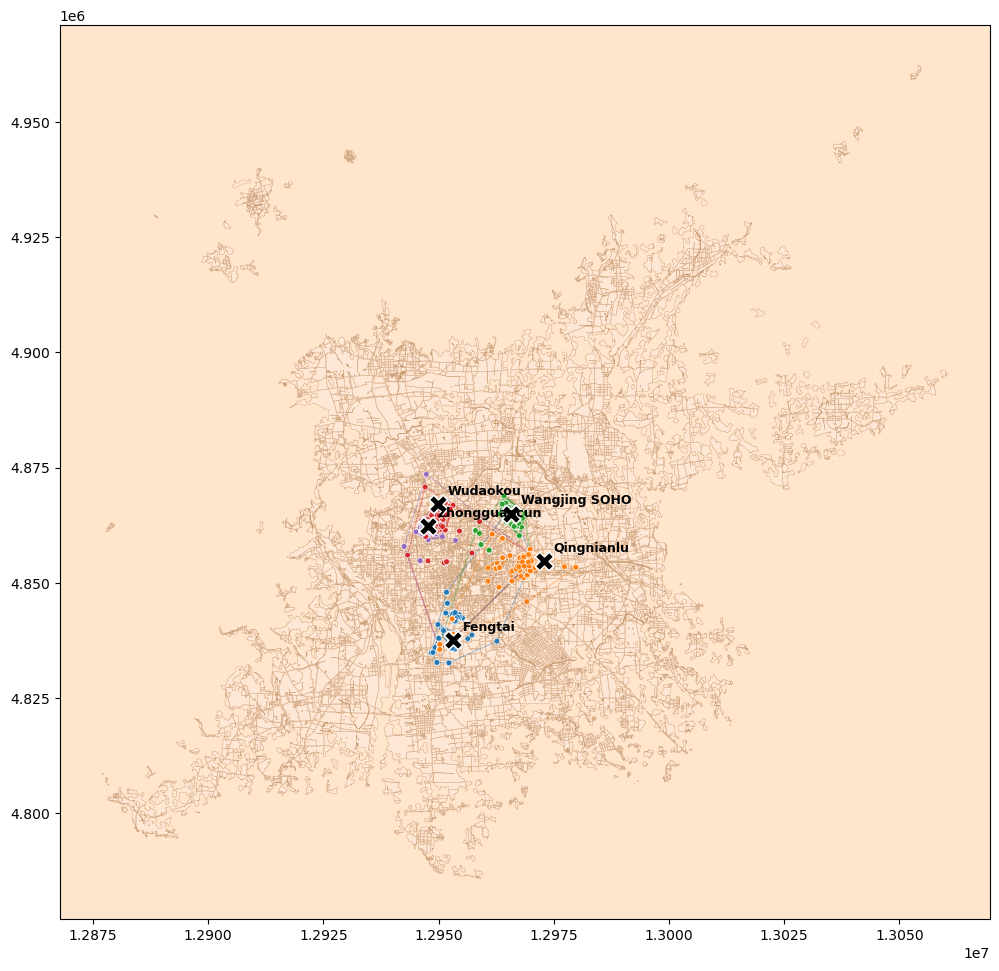

In [ ]:
fig, ax = make_base_map()

draw_overall_hulls(ax)
draw_cluster_hulls(ax)
draw_restaurants(ax)
draw_observation_sites(ax)

plt.show()

### Kernel restart note

If the kernel is restarted, run the notebook from the top or at least run the helper/setup cells before the plotting cells. The `set_centered_extent()` helper is now included directly before its first use.


In [ ]:
def set_centered_extent(
    ax,
    center_x,
    center_y,
    padding_ratio=0.08,
):

    restaurant_bounds = delivery_gdf_web.total_bounds
    observation_bounds = observation_gdf_web.total_bounds

    minx = min(
        restaurant_bounds[0],
        observation_bounds[0],
    )

    miny = min(
        restaurant_bounds[1],
        observation_bounds[1],
    )

    maxx = max(
        restaurant_bounds[2],
        observation_bounds[2],
    )

    maxy = max(
        restaurant_bounds[3],
        observation_bounds[3],
    )

    # Find the largest distance from the Forbidden City center
    half_width = max(
        center_x - minx,
        maxx - center_x,
    )

    half_height = max(
        center_y - miny,
        maxy - center_y,
    )

    # Use one shared radius so the view stays square
    radius = max(
        half_width,
        half_height,
    )

    radius *= 1 + padding_ratio

    ax.set_xlim(
        center_x - radius,
        center_x + radius,
    )

    ax.set_ylim(
        center_y - radius,
        center_y + radius,
    )

In [ ]:
# ============================================================
# HELPER — centered crop / extent
# ============================================================

def set_centered_extent(ax, center_x, center_y, width, height=None):
    """
    Set a map crop centered on (center_x, center_y).

    Parameters
    ----------
    ax : matplotlib axis
    center_x, center_y : projected coordinates
    width : crop width in map units
    height : crop height in map units; if None, uses width
    """
    if height is None:
        height = width

    ax.set_xlim(
        center_x - width / 2,
        center_x + width / 2
    )

    ax.set_ylim(
        center_y - height / 2,
        center_y + height / 2
    )

    ax.set_aspect("equal")


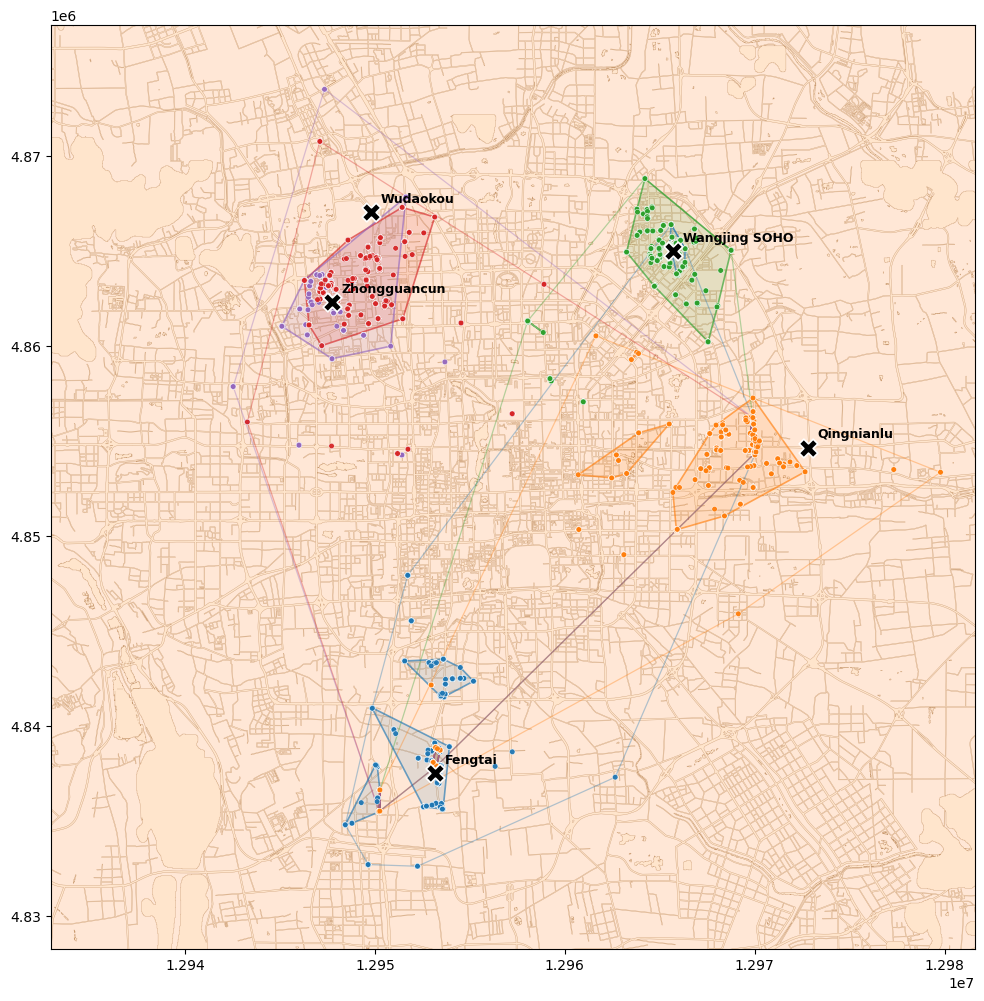

In [ ]:
fig, ax = make_base_map()

draw_overall_hulls(ax)
draw_cluster_hulls(ax)
draw_restaurants(ax)
draw_observation_sites(ax)

set_centered_extent(
    ax,
    center_x,
    center_y,
)

plt.show()

In [37]:
def set_centered_extent(ax, center_x, center_y, width, height=None):
    if height is None:
        height = width

    ax.set_xlim(center_x - width / 2, center_x + width / 2)

    ax.set_ylim(center_y - height / 2, center_y + height / 2)

TypeError: set_centered_extent() missing 1 required positional argument: 'width'

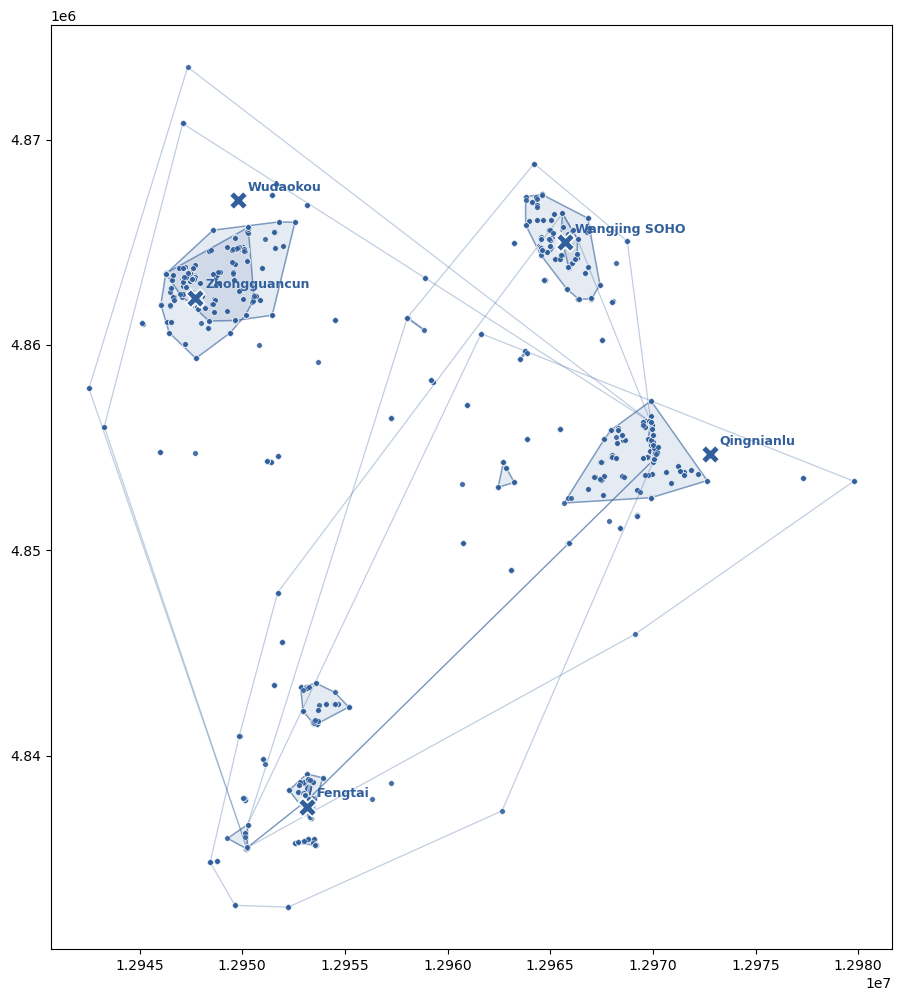

In [38]:
# --------------------------------------------------
# Final blue diagram
# Create clusters + draw everything in ONE cell
# --------------------------------------------------

import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import DBSCAN

BLUE = "#315F9B"

# DBSCAN parameters
# delivery_gdf_web is EPSG:3857, so eps is measured in metres
EPS = 1000
MIN_SAMPLES = 5


# --------------------------------------------------
# 1. Create cluster hulls
# --------------------------------------------------

cluster_hulls = []

for address_name, group in delivery_gdf_web.groupby(
    "address_en",
    observed=True,
):
    group = group.copy()

    if len(group) < MIN_SAMPLES:
        continue

    coordinates = np.column_stack(
        [
            group.geometry.x,
            group.geometry.y,
        ]
    )

    group["cluster_id"] = DBSCAN(
        eps=EPS,
        min_samples=MIN_SAMPLES,
    ).fit_predict(coordinates)

    # DBSCAN label -1 means noise
    clustered = group[group["cluster_id"] != -1]

    for cluster_id, cluster_group in clustered.groupby("cluster_id"):
        hull = cluster_group.geometry.union_all().convex_hull

        if hull.geom_type != "Polygon":
            continue

        cluster_hulls.append(
            {
                "address_en": address_name,
                "cluster_id": cluster_id,
                "geometry": hull,
            }
        )


# --------------------------------------------------
# 2. Create blank figure — no Beijing basemap
# --------------------------------------------------

fig, ax = plt.subplots(figsize=(12, 12))

fig.patch.set_facecolor("white")
ax.set_facecolor("white")


# --------------------------------------------------
# 3. Overall hulls — outline only
# --------------------------------------------------

for address_name, group in delivery_gdf_web.groupby(
    "address_en",
    observed=True,
):
    hull = group.geometry.union_all().convex_hull

    if hull.geom_type != "Polygon":
        continue

    x, y = hull.exterior.xy

    ax.plot(
        x,
        y,
        color=BLUE,
        linewidth=0.9,
        alpha=0.30,
        zorder=1,
    )


# --------------------------------------------------
# 4. Cluster hulls — fill only detected clusters
# --------------------------------------------------

for cluster in cluster_hulls:
    hull = cluster["geometry"]

    x, y = hull.exterior.xy

    ax.fill(
        x,
        y,
        facecolor=BLUE,
        alpha=0.12,
        linewidth=0,
        zorder=2,
    )

    ax.plot(
        x,
        y,
        color=BLUE,
        linewidth=1.1,
        alpha=0.60,
        zorder=3,
    )


# --------------------------------------------------
# 5. Restaurant points
# --------------------------------------------------

delivery_gdf_web.plot(
    ax=ax,
    color=BLUE,
    markersize=16,
    alpha=0.90,
    edgecolor="white",
    linewidth=0.35,
    zorder=4,
)


# --------------------------------------------------
# 6. Observation sites
# --------------------------------------------------

observation_gdf_web.plot(
    ax=ax,
    marker="X",
    markersize=180,
    color=BLUE,
    edgecolor="white",
    linewidth=1.2,
    zorder=10,
)

for _, row in observation_gdf_web.iterrows():
    ax.annotate(
        row["address_en"],
        (row.geometry.x, row.geometry.y),
        xytext=(7, 7),
        textcoords="offset points",
        fontsize=9,
        fontweight="bold",
        color=BLUE,
        zorder=11,
    )


# --------------------------------------------------
# 7. Same crop as original diagram
# --------------------------------------------------

set_centered_extent(
    ax,
    center_x,
    center_y,
)

ax.set_aspect("equal")
ax.axis("off")

plt.tight_layout()
plt.show()

print(f"Created {len(cluster_hulls)} cluster hulls.")

# Shared-location inset analysis

This section finds **different restaurant listings that occupy the same or nearly the same location** and makes a small zoom / exploded-view figure for presentation.

The code is written so it can rebuild `delivery_gdf_web` from `Meituan_final.csv` if needed.


In [ ]:
# ============================================================
# 1. SETUP — faster version
# ============================================================

import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt

from sklearn.cluster import DBSCAN

TARGET_SITE = "五道口"
EPS_METERS = 50

# ------------------------------------------------------------
# 1. Read only what we need
# ------------------------------------------------------------

delivery_data = pd.read_csv(
    "Meituan_final.csv",
    usecols=[
        "shop_name",
        "address",
        "lng",
        "lat",
    ],
)

# ------------------------------------------------------------
# 2. Filter site FIRST
# ------------------------------------------------------------

site_data = delivery_data[delivery_data["address"].astype(str) == TARGET_SITE].copy()

if TARGET_SITE == "丰台" and len(site_data) == 0:
    site_data = delivery_data[
        delivery_data["address"].astype(str).isin(["丰台", "丰台区"])
    ].copy()

# ------------------------------------------------------------
# 3. Clean coordinates
# ------------------------------------------------------------

site_data["lng"] = pd.to_numeric(site_data["lng"], errors="coerce")

site_data["lat"] = pd.to_numeric(site_data["lat"], errors="coerce")

site_data = site_data.dropna(subset=["lng", "lat"]).copy()

# Optional Beijing sanity check
site_data = site_data[
    site_data["lng"].between(115, 118) & site_data["lat"].between(38, 42)
].copy()

# ------------------------------------------------------------
# 4. Deduplicate restaurant names BEFORE projection
# ------------------------------------------------------------

site_unique = site_data.drop_duplicates(subset=["shop_name"]).copy()

# ------------------------------------------------------------
# 5. Only now build GeoDataFrame + project
# ------------------------------------------------------------

site_unique = gpd.GeoDataFrame(
    site_unique,
    geometry=gpd.points_from_xy(
        site_unique["lng"],
        site_unique["lat"],
    ),
    crs="EPSG:4326",
)

site_unique = site_unique.to_crs(epsg=3857)

print("Site:", TARGET_SITE)
print("Unique restaurant names:", len(site_unique))

site_unique.head()

Site: 五道口
Unique restaurant names: 171


,shop_name,lng,lat,address,geometry
3272,田老师红烧肉（中关村物美店）,116.311182,39.981863,五道口,POINT (12947701.545 4863307.007)
3273,汉堡王（五道口餐厅19195店）,116.327834,39.991205,五道口,POINT (12949555.213 4864664.259)
3274,桃园煲仔饭（五道口店）,116.327612,39.986787,五道口,POINT (12949530.507 4864022.439)
3275,沙县小吃（第2风味+北京洪火火餐饮管理有限公司）,116.305935,39.976221,五道口,POINT (12947117.474 4862487.371)
3277,东北饺子馆（五道口店）,116.328499,39.986148,五道口,POINT (12949629.253 4863929.503)


In [ ]:
# ============================================================
# 1. SETUP — rebuild restaurant GeoDataFrame if needed
# ============================================================

import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt

from sklearn.cluster import DBSCAN
from shapely.geometry import Point

# ------------------------------------------------------------
# Editable settings
# ------------------------------------------------------------

TARGET_SITE = "五道口"  # try: 五道口 / 中关村 / 望京SOHO / 青年路 / 丰台
EPS_METERS = 50  # restaurants within 50 m are treated as one near-shared location

# ------------------------------------------------------------
# Rebuild delivery_gdf_web if this section is run independently
# ------------------------------------------------------------

if "delivery_gdf_web" not in globals():

    delivery_data = pd.read_csv("Meituan_final.csv")

    mapped_data = delivery_data.dropna(subset=["lng", "lat"]).copy()

    delivery_gdf = gpd.GeoDataFrame(
        mapped_data,
        geometry=gpd.points_from_xy(
            mapped_data["lng"],
            mapped_data["lat"],
        ),
        crs="EPSG:4326",
    )

    delivery_gdf_web = delivery_gdf.to_crs(epsg=3857)

# ------------------------------------------------------------
# Keep only the selected observation site
# ------------------------------------------------------------

site_data = delivery_gdf_web[
    delivery_gdf_web["address"].astype(str) == TARGET_SITE
].copy()

# Some files may use 丰台区 instead of 丰台
if TARGET_SITE == "丰台" and len(site_data) == 0:
    site_data = delivery_gdf_web[
        delivery_gdf_web["address"].astype(str).isin(["丰台", "丰台区"])
    ].copy()

# ------------------------------------------------------------
# Remove the same restaurant repeated across rows/modules
# so clusters represent DIFFERENT restaurant names
# ------------------------------------------------------------

site_unique = site_data.drop_duplicates(subset=["shop_name"]).copy()

print("Site:", TARGET_SITE)
print("Rows before shop-name deduplication:", len(site_data))
print("Unique restaurant names:", len(site_unique))

site_unique.head()

Site: 五道口
Rows before shop-name deduplication: 1720
Unique restaurant names: 171


,shop_name,lng,lat,address,module,time,geometry
3272,田老师红烧肉（中关村物美店）,116.311182,39.981863,五道口,拼好饭,中午,POINT (12947701.545 4863307.007)
3273,汉堡王（五道口餐厅19195店）,116.327834,39.991205,五道口,拼好饭,中午,POINT (12949555.213 4864664.259)
3274,桃园煲仔饭（五道口店）,116.327612,39.986787,五道口,拼好饭,中午,POINT (12949530.507 4864022.439)
3275,沙县小吃（第2风味+北京洪火火餐饮管理有限公司）,116.305935,39.976221,五道口,拼好饭,中午,POINT (12947117.474 4862487.371)
3277,东北饺子馆（五道口店）,116.328499,39.986148,五道口,拼好饭,中午,POINT (12949629.253 4863929.503)


In [ ]:
# ============================================================
# 2. FIND NEAR-SHARED LOCATIONS WITH DBSCAN
# ============================================================

points = np.column_stack(
    [
        site_unique.geometry.x,
        site_unique.geometry.y,
    ]
)

db = DBSCAN(
    eps=EPS_METERS,
    min_samples=2,
).fit(points)

site_unique["shared_location_cluster"] = db.labels_

shared = site_unique[site_unique["shared_location_cluster"] != -1].copy()

cluster_summary = (
    shared.groupby("shared_location_cluster")
    .agg(
        restaurant_count=("shop_name", "nunique"),
        center_x=("geometry", lambda g: g.x.mean()),
        center_y=("geometry", lambda g: g.y.mean()),
    )
    .sort_values(
        "restaurant_count",
        ascending=False,
    )
)

print(f"Near-shared clusters found within {EPS_METERS} m:", len(cluster_summary))

cluster_summary.head(15)

Near-shared clusters found within 50 m: 23


,restaurant_count,center_x,center_y
shared_location_cluster,,,
5,11,1.294887e+07,4.863551e+06
9,11,1.294980e+07,4.864746e+06
12,10,1.295014e+07,4.864568e+06
1,9,1.294954e+07,4.864020e+06
6,7,1.295050e+07,4.862159e+06
3,6,1.294954e+07,4.863467e+06
19,5,1.295028e+07,4.865685e+06
0,4,1.294955e+07,4.864657e+06
20,3,1.294857e+07,4.861971e+06


In [ ]:
# ============================================================
# 3. SELECT A CLUSTER AND INSPECT ITS RESTAURANTS
# ============================================================

if len(cluster_summary) == 0:
    raise ValueError(
        f"No clusters found within {EPS_METERS} m. "
        "Try increasing EPS_METERS to 75 or 100."
    )

# 0 = largest cluster
# Change to 1, 2, 3... to inspect another cluster
CLUSTER_RANK = 0

TARGET_CLUSTER = cluster_summary.index[CLUSTER_RANK]

target = shared[shared["shared_location_cluster"] == TARGET_CLUSTER].copy()

print("Cluster ID:", TARGET_CLUSTER)
print("Distinct restaurants:", target["shop_name"].nunique())

display_cols = [
    c
    for c in [
        "shop_name",
        "address",
        "lng",
        "lat",
    ]
    if c in target.columns
]

target[display_cols].sort_values("shop_name")

Cluster ID: 5
Distinct restaurants: 11


,shop_name,address,lng,lat
4652,一家被炒面耽误的炒饭店（第十九档口-吉祥厨房美食城店）,五道口,116.321509,39.983567
4718,一碗赌上厨师生涯的炒饭·王者炒饭（中关村吉祥厨房美食城店）,五道口,116.321282,39.983651
4531,上海本帮现炒浇头面（中关村店）,五道口,116.321770,39.983450
3614,半亩良田（排骨米饭·五道口店）,五道口,116.321502,39.983604
4535,嘎嘎香东北老饭盒（第1档口+天天快厨美食城店）,五道口,116.322073,39.983666
4638,王者蛋炒饭·走出扬州（中关村店）,五道口,116.321502,39.983604
4121,祁姥姥家的疙瘩汤（第一档口吉祥厨房美食城店）,五道口,116.321777,39.983476
3432,肴可及脆皮鸡烤肉饭（第13档口-吉祥美食城店),五道口,116.321752,39.983525
4536,饿熊便当（五道口店）,五道口,116.321641,39.983323
3423,驴火先生·新中式汉堡（第2档口-吉祥美食城店）,五道口,116.321555,39.983603


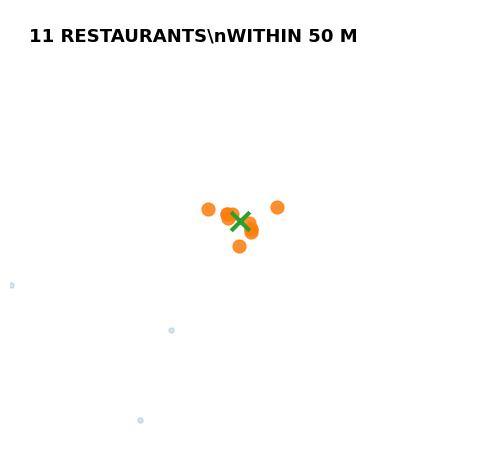

In [ ]:
# ============================================================
# 4. ZOOM-IN MAP — TRUE RESTAURANT LOCATIONS
# ============================================================

fig, ax = plt.subplots(figsize=(6, 6))

xmin, ymin, xmax, ymax = target.total_bounds

# Keep enough context even when points are nearly identical
padding = max(
    250,
    (xmax - xmin) * 2,
    (ymax - ymin) * 2,
)

ax.set_xlim(
    xmin - padding,
    xmax + padding,
)

ax.set_ylim(
    ymin - padding,
    ymax + padding,
)

# Other restaurants nearby
nearby = site_unique.cx[
    xmin - padding : xmax + padding,
    ymin - padding : ymax + padding,
]

nearby.plot(
    ax=ax,
    markersize=14,
    alpha=0.18,
    zorder=2,
)

# Selected near-shared restaurants
target.plot(
    ax=ax,
    markersize=85,
    alpha=0.85,
    zorder=5,
)

# Cluster center
cx = target.geometry.x.mean()
cy = target.geometry.y.mean()

ax.scatter(
    cx,
    cy,
    marker="x",
    s=180,
    linewidth=3,
    zorder=10,
)

ax.text(
    0.04,
    0.96,
    f"{target['shop_name'].nunique()} RESTAURANTS\\nWITHIN {EPS_METERS} M",
    transform=ax.transAxes,
    ha="left",
    va="top",
    fontsize=13,
    fontweight="bold",
)

ax.set_aspect("equal")
ax.set_axis_off()

plt.show()

In [ ]:
# ============================================================
# 5. EXPLODED VIEW — REVEAL OVERLAPPING RESTAURANT LISTINGS
# ============================================================

fig, ax = plt.subplots(figsize=(7, 7))

# True cluster center
cx = target.geometry.x.mean()
cy = target.geometry.y.mean()

names = target.drop_duplicates(subset=["shop_name"])["shop_name"].astype(str).tolist()

n = len(names)

# Purely visual offset; NOT geographic displacement
EXPLODE_RADIUS_M = 150

angles = np.linspace(
    0,
    2 * np.pi,
    n,
    endpoint=False,
)

display_x = cx + EXPLODE_RADIUS_M * np.cos(angles)
display_y = cy + EXPLODE_RADIUS_M * np.sin(angles)

# Lines return each visually separated listing to the true shared-location center
for x, y in zip(display_x, display_y):
    ax.plot(
        [cx, x],
        [cy, y],
        linewidth=0.8,
        alpha=0.45,
        zorder=2,
    )

ax.scatter(
    display_x,
    display_y,
    s=95,
    zorder=5,
)

# True location
ax.scatter(
    cx,
    cy,
    marker="x",
    s=210,
    linewidth=3,
    zorder=10,
)

# Restaurant labels
for x, y, name in zip(
    display_x,
    display_y,
    names,
):
    ax.text(
        x,
        y + 18,
        name,
        fontsize=7,
        ha="center",
        va="bottom",
    )

ax.text(
    0.04,
    0.96,
    f"{n} RESTAURANTS\\n1 NEAR-SHARED LOCATION",
    transform=ax.transAxes,
    ha="left",
    va="top",
    fontsize=13,
    fontweight="bold",
)

ax.text(
    0.04,
    0.04,
    "Points are visually offset to reveal overlapping listings.",
    transform=ax.transAxes,
    fontsize=8,
    alpha=0.6,
)

margin = EXPLODE_RADIUS_M * 1.8

ax.set_xlim(
    cx - margin,
    cx + margin,
)
ax.set_ylim(
    cy - margin,
    cy + margin,
)

ax.set_aspect("equal")
ax.set_axis_off()

plt.show()

### How to use this in the presentation

Use the **zoom-in map** to show that the restaurants occupy almost the same real location.

Use the **exploded view** to make otherwise overlapping restaurant listings legible.

Suggested caption:

> Multiple restaurant listings converge on the same or nearly identical spatial location. Points are visually offset only to reveal overlap.
